# Speech Emotion Recognition walkthrough

Predicting emotion in speech from MFCC / chroma / mel features with a
scikit-learn `MLPClassifier`, on the RAVDESS dataset.

This goes through the same steps as the code in `src/speech_emotion/`: one clip
-> 180 numbers -> trained model -> evaluation on speakers it hasn't heard.

**Before running:** `python scripts/download_dataset.py`

---

### Contents
1. [Setup](#1)
2. [The data](#2)
3. [From audio to features](#3)
4. [Building the feature matrix](#4)
5. [Looking at the features](#5)
6. [Baseline: random split](#6)
7. [Speaker split](#7)
8. [All eight emotions](#8)
9. [Predicting one file](#9)
10. [Summary](#10)

<a id='1'></a>
## 1. Setup

In [1]:
import sys, warnings
from pathlib import Path

# so `src/` can be imported from the repo root or from notebooks/
REPO_ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile
from IPython.display import Audio, display

from speech_emotion import EMOTIONS, OBSERVED_EMOTIONS, extract_feature, load_dataset
from speech_emotion.dataset import find_audio_files, parse_ravdess_filename

DATA_DIR = REPO_ROOT / 'data' / 'ravdess'
CACHE = REPO_ROOT / 'data' / 'features_cache.npz'
RANDOM_STATE = 9

print(f'librosa {librosa.__version__} | numpy {np.__version__}')
print(f'data dir: {DATA_DIR}')

librosa 1.0.0 | numpy 2.5.3
data dir: data/ravdess


<a id='2'></a>
## 2. The data

RAVDESS doesn't have a labels file, the labels are in the filename. There are 7
fields separated by hyphens: the 3rd is the emotion and the 7th is the actor.

`03-01-06-01-02-01-12.wav` = audio-only, speech, **fearful**, normal intensity,
statement 2, repetition 1, **actor 12** (even, so female).

In [2]:
files = find_audio_files(DATA_DIR)
print(f'Found {len(files)} wav files')

meta = pd.DataFrame([vars(parse_ravdess_filename(f)) | {'gender': parse_ravdess_filename(f).gender}
                     for f in files])
meta.head()

Found 1440 wav files


,path,emotion,intensity,statement,repetition,actor,gender
0,data/ravdess/Acto...,neutral,normal,kids_talking,1,1,male
1,data/ravdess/Acto...,neutral,normal,kids_talking,2,1,male
2,data/ravdess/Acto...,neutral,normal,dogs_sitting,1,1,male
3,data/ravdess/Acto...,neutral,normal,dogs_sitting,2,1,male
4,data/ravdess/Acto...,calm,normal,kids_talking,1,1,male


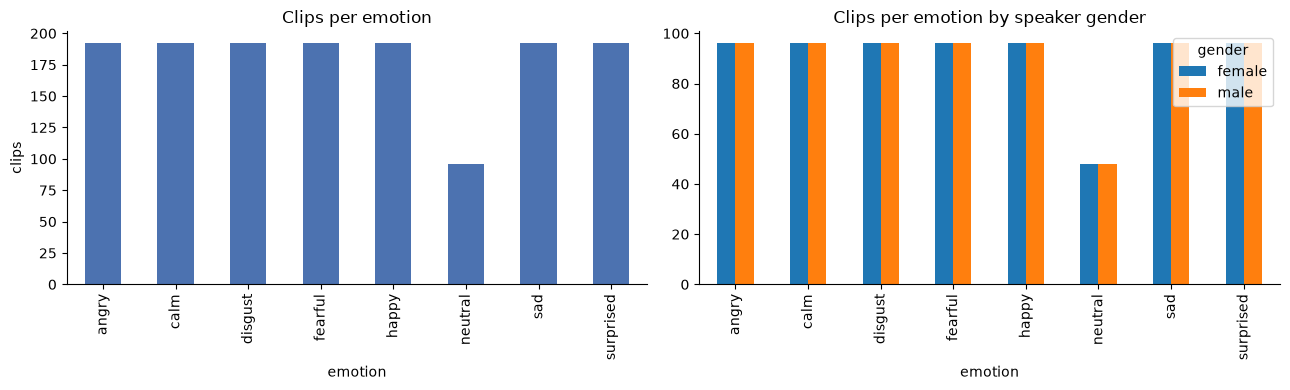

emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64


In [3]:
# class balance. neutral has half as many clips because it has no 'strong' version
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
meta['emotion'].value_counts().sort_index().plot.bar(ax=axes[0], color='#4C72B0')
axes[0].set_title('Clips per emotion'); axes[0].set_ylabel('clips')
meta.groupby(['emotion', 'gender']).size().unstack().plot.bar(ax=axes[1])
axes[1].set_title('Clips per emotion by speaker gender')
for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print(meta['emotion'].value_counts().sort_index())

The four emotions used for the baseline (`calm`, `happy`, `fearful`,
`disgust`) have exactly 192 clips each, so plain accuracy is fine as a metric
and chance is 25%. Leaving out `neutral` also avoids the neutral/calm
confusion, which even human raters struggle with.

In [4]:
# one clip per emotion + waveform
for emotion in OBSERVED_EMOTIONS:
    row = meta[meta['emotion'] == emotion].iloc[0]
    y, sr = librosa.load(row['path'], sr=None)
    print(f"{emotion:<9} actor {row['actor']:>2} ({row['gender']})  "
          f"{len(y)/sr:.2f}s @ {sr} Hz")
    display(Audio(data=y, rate=sr))

calm      actor  1 (male)  3.54s @ 48000 Hz


happy     actor  1 (male)  3.47s @ 48000 Hz


fearful   actor  1 (male)  3.67s @ 48000 Hz


disgust   actor  1 (male)  3.87s @ 48000 Hz


<a id='3'></a>
## 3. From audio to features

Clips are different lengths, but `MLPClassifier.fit` needs every row to be the
same size. The usual trick is to compute features per frame and then average
each one over time, so every clip ends up as the same length vector.

| Feature | Dims | Roughly captures |
|---|---:|---|
| MFCC | 40 | timbre (vocal tract shape) |
| Chroma | 12 | energy per pitch class |
| Mel spectrogram | 128 | energy across frequency bands |

180 features in total.

In [5]:
sample = meta[meta['emotion'] == 'fearful'].iloc[0]['path']
y, sr = librosa.load(sample, sr=None)

stft = np.abs(librosa.stft(y=y))
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
chroma = librosa.feature.chroma_stft(S=stft, sr=sr)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)

print(f'{"MFCC":<8} {mfcc.shape}   (coefficients x time frames)')
print(f'{"Chroma":<8} {chroma.shape}')
print(f'{"Mel":<8} {mel.shape}')
print(f'\nAfter averaging over time: {40 + 12 + 128} features')

MFCC     (40, 345)   (coefficients x time frames)
Chroma   (12, 345)
Mel      (128, 345)

After averaging over time: 180 features


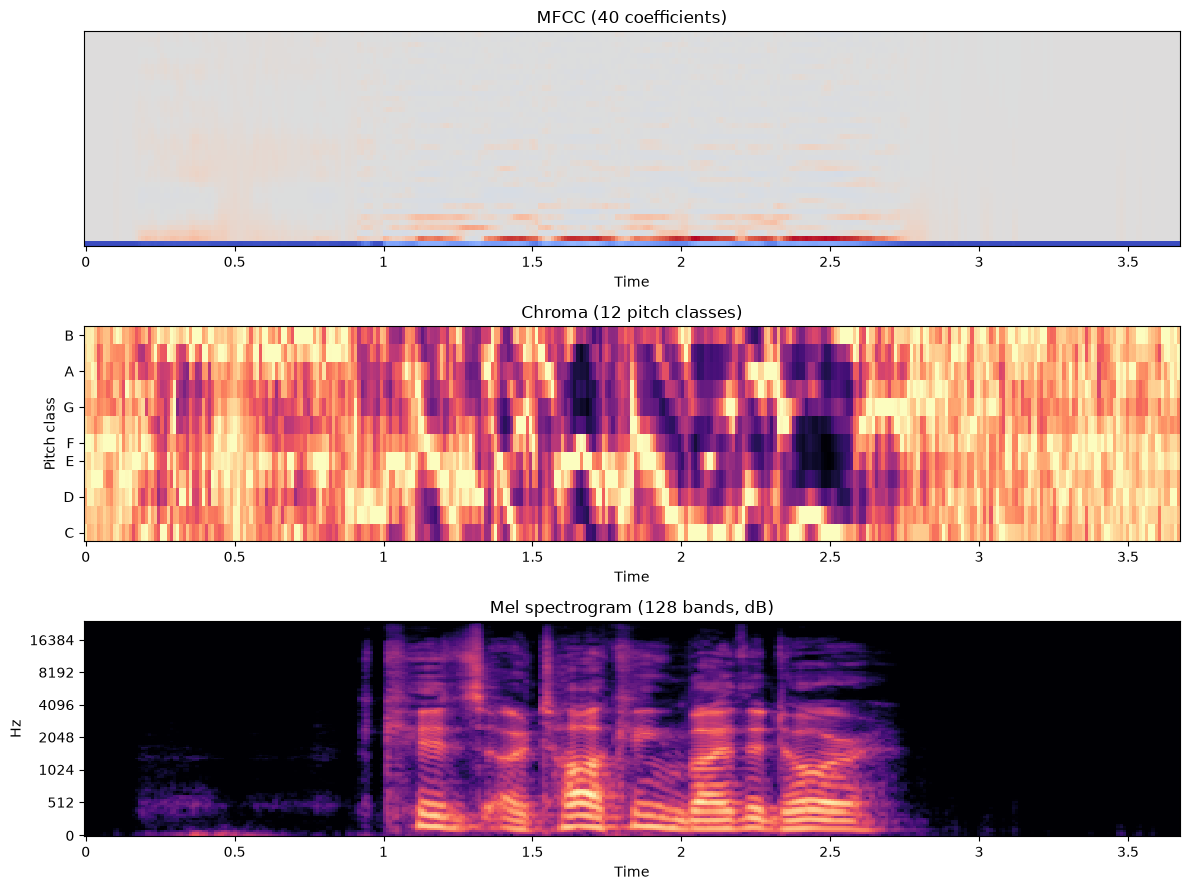

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
librosa.display.specshow(mfcc, x_axis='time', sr=sr, ax=axes[0])
axes[0].set_title('MFCC (40 coefficients)')
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', sr=sr, ax=axes[1])
axes[1].set_title('Chroma (12 pitch classes)')
librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                         y_axis='mel', x_axis='time', sr=sr, ax=axes[2])
axes[2].set_title('Mel spectrogram (128 bands, dB)')
plt.tight_layout(); plt.show()

**Downside of averaging:** the order of frames is lost. A pitch contour that
rises at the end and one that falls at the end have the same mean, so they give
the same vector. But that contour is a lot of what makes something sound like a
question, or surprised rather than angry. I think this is the biggest limit of
this approach and the main reason CNNs on the spectrogram do better.

In [7]:
features = extract_feature(sample, mfcc=True, chroma=True, mel=True)
print(f'shape: {features.shape}')
print(f'first 8 values: {np.round(features[:8], 3)}')

# 0.5s and 3.7s clips both give 180 features
for seconds in (0.5, 3.7):
    t = np.linspace(0, seconds, int(48000 * seconds), endpoint=False)
    tmp = REPO_ROOT / f'tone_{seconds}.wav'
    soundfile.write(tmp, (0.4 * np.sin(2*np.pi*220*t)).astype('float32'), 48000)
    print(f'{seconds}s clip -> {extract_feature(tmp).shape}')
    tmp.unlink()

shape: (180,)
first 8 values: [-620.869   72.926    3.07    15.846    5.005   15.863   -6.974    2.558]
0.5s clip -> (180,)
3.7s clip -> (180,)


<a id='4'></a>
## 4. Building the feature matrix

Extracting features is the slow part (a minute or two for 1,440 clips), while
training the MLP takes seconds. So the features get cached to an `.npz` file.

`load_dataset` also returns `groups`, the actor id for each clip, which is
needed for section 7.

In [8]:
%%time
X, y, groups = load_dataset(DATA_DIR, OBSERVED_EMOTIONS, cache_path=CACHE)
print(f'\nX: {X.shape}   y: {y.shape}   unique actors: {len(np.unique(groups))}')

Loaded cached features from data/features_cache.npz (768 of 1440 clips match the requested emotions)

X: (768, 180)   y: (768,)   unique actors: 24
CPU times: user 5.23 ms, sys: 263 μs, total: 5.49 ms
Wall time: 5.48 ms


<a id='5'></a>
## 5. Looking at the features

Quick check before training: do the emotions actually look different in these
features? If the average curve for every emotion was the same, no classifier
would be able to separate them.

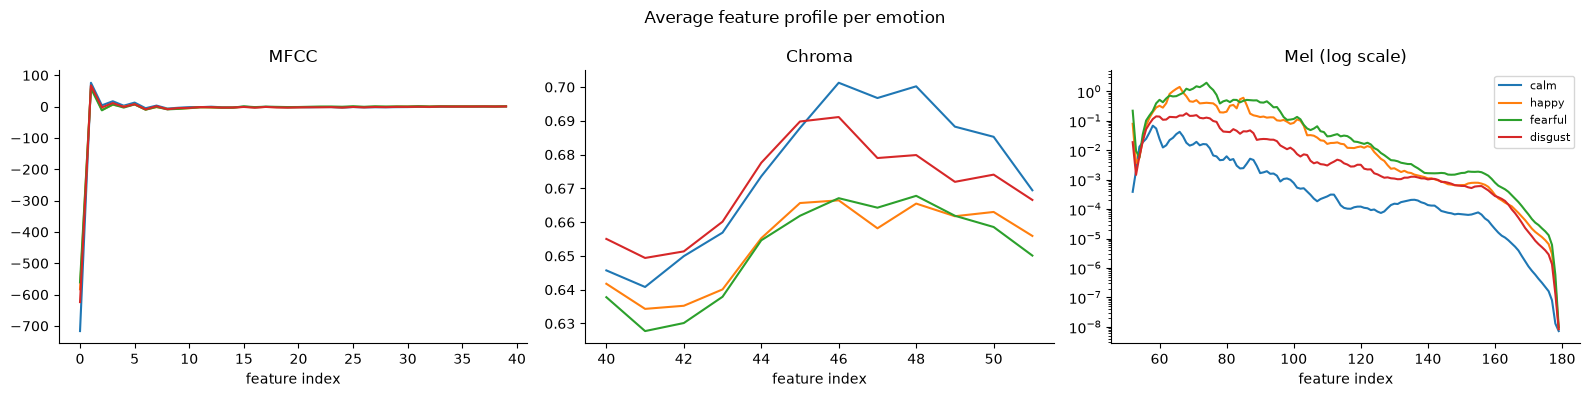

In [9]:
from speech_emotion.features import N_CHROMA, N_MEL, N_MFCC

blocks = [('MFCC', 0, N_MFCC),
          ('Chroma', N_MFCC, N_MFCC + N_CHROMA),
          ('Mel (log scale)', N_MFCC + N_CHROMA, 180)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (title, lo, hi) in zip(axes, blocks):
    for emotion in OBSERVED_EMOTIONS:
        ax.plot(range(lo, hi), X[y == emotion, lo:hi].mean(axis=0), label=emotion, lw=1.5)
    ax.set_title(title); ax.set_xlabel('feature index')
    ax.spines[['top','right']].set_visible(False)
    if title.startswith('Mel'): ax.set_yscale('log')
axes[-1].legend(fontsize=8)
plt.suptitle('Average feature profile per emotion'); plt.tight_layout(); plt.show()

The mel panel shows the clearest difference, with the high-energy emotions
having more energy across the bands. This comes up again later: these features
are better at **arousal** (how activated someone sounds) than **valence**
(positive vs negative).

In [10]:
# the features are on very different scales, hence StandardScaler
scale = pd.DataFrame({
    'block': ['mfcc']*N_MFCC + ['chroma']*N_CHROMA + ['mel']*N_MEL,
    'std': X.std(axis=0), 'mean': X.mean(axis=0),
}).groupby('block').agg(['min', 'max'])
scale.round(3)

std             mean        
          min     max      min     max
block                                 
chroma  0.075   0.099    0.638   0.681
mel     0.000   4.801    0.000   0.634
mfcc    1.982  98.726 -621.124  67.071

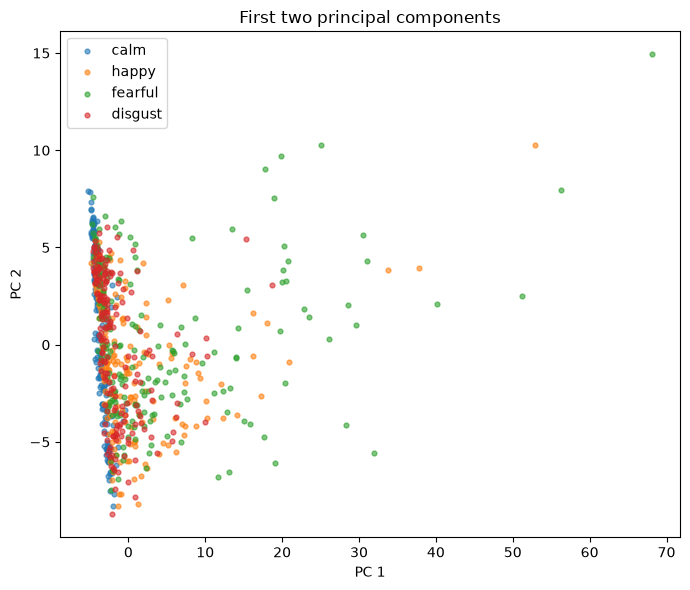

In [11]:
# 2D PCA. The classes overlap a lot, so a linear model probably isn't enough
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pcs = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(
    StandardScaler().fit_transform(X))
plt.figure(figsize=(7, 6))
for emotion in OBSERVED_EMOTIONS:
    m = y == emotion
    plt.scatter(pcs[m, 0], pcs[m, 1], s=12, alpha=0.6, label=emotion)
plt.legend(); plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.title('First two principal components'); plt.tight_layout(); plt.show()

<a id='6'></a>
## 6. Baseline: random split

This is the tutorial setup: shuffle all clips and hold out 25%. I kept the
tutorial's MLP settings so the result is comparable, and only added a
`StandardScaler` inside a `Pipeline` (so it's fitted on the training data only).

In [12]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

def build_model(scale=True):
    mlp = MLPClassifier(alpha=0.01, batch_size=256, epsilon=1e-08,
                        hidden_layer_sizes=(300,), learning_rate='adaptive',
                        max_iter=500, random_state=RANDOM_STATE)
    steps = ([('scaler', StandardScaler())] if scale else []) + [('mlp', mlp)]
    return Pipeline(steps)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print(f'train / test clips: {X_train.shape[0]} / {X_test.shape[0]}')
print(f'features extracted: {X_train.shape[1]}')

train / test clips: 576 / 192
features extracted: 180


In [13]:
model = build_model()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc_random = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc_random*100:.2f}%\n')
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 77.60%

              precision    recall  f1-score   support

        calm       0.86      0.90      0.88        48
     disgust       0.79      0.69      0.73        48
     fearful       0.79      0.71      0.75        48
       happy       0.68      0.81      0.74        48

    accuracy                           0.78       192
   macro avg       0.78      0.78      0.78       192
weighted avg       0.78      0.78      0.78       192



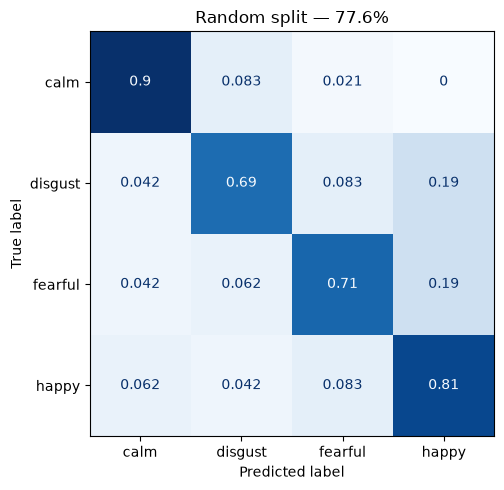

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, normalize='true',
                                      cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Random split — {acc_random:.1%}')
plt.tight_layout(); plt.show()

In [15]:
# how much does the scaler help?
raw = build_model(scale=False).fit(X_train, y_train)
acc_raw = accuracy_score(y_test, raw.predict(X_test))
print(f'with StandardScaler:    {acc_random*100:.2f}%')
print(f'without StandardScaler: {acc_raw*100:.2f}%')
print(f'difference:             {(acc_random-acc_raw)*100:+.2f} pp')

with StandardScaler:    77.60%
without StandardScaler: 71.35%
difference:             +6.25 pp


<a id='7'></a>
## 7. Speaker split

### What's wrong with the random split

Every actor has 60 clips, so a random shuffle puts the same voice in both train
and test. Some of actor 14's happy clips are used for training and others for
testing.

That means the model can partly get the answer by recognising the voice. That
doesn't work on a new speaker, which is the whole point of using it.

To fix it, use `GroupShuffleSplit` with `groups=actor_id` so whole actors are
held out.

In [16]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

print(f'train actors: {sorted(set(groups[train_idx].tolist()))}')
print(f'test actors:  {sorted(set(groups[test_idx].tolist()))}  <- never heard during training')
assert not set(groups[train_idx]) & set(groups[test_idx]), 'speaker leak!'

Xtr, Xte = X[train_idx], X[test_idx]
ytr, yte = y[train_idx], y[test_idx]

train actors: [1, 2, 3, 7, 9, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24]
test actors:  [4, 5, 6, 8, 10, 19]  <- never heard during training


In [17]:
speaker_model = build_model().fit(Xtr, ytr)
y_pred_sp = speaker_model.predict(Xte)
acc_speaker = accuracy_score(yte, y_pred_sp)

print(f'Random split  (same voices in train & test): {acc_random*100:.2f}%')
print(f'Speaker split (unseen voices):               {acc_speaker*100:.2f}%')
print(f'Gap:                                         {(acc_random-acc_speaker)*100:.2f} pp')
print()
print(classification_report(yte, y_pred_sp, zero_division=0))

Random split  (same voices in train & test): 77.60%
Speaker split (unseen voices):               59.38%
Gap:                                         18.23 pp

              precision    recall  f1-score   support

        calm       0.68      0.67      0.67        48
     disgust       0.62      0.54      0.58        48
     fearful       0.55      0.69      0.61        48
       happy       0.53      0.48      0.51        48

    accuracy                           0.59       192
   macro avg       0.60      0.59      0.59       192
weighted avg       0.60      0.59      0.59       192



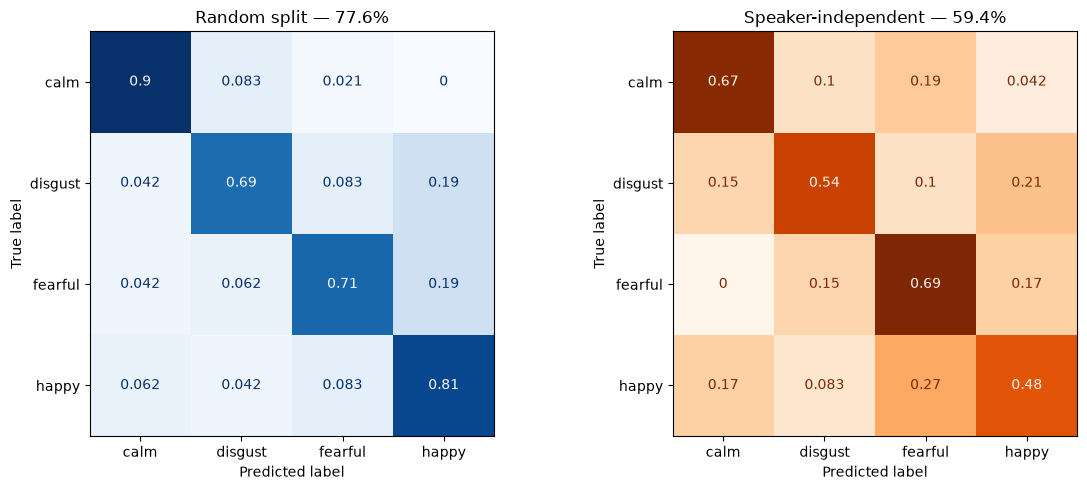

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, normalize='true',
                                      cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Random split — {acc_random:.1%}')
ConfusionMatrixDisplay.from_estimator(speaker_model, Xte, yte, normalize='true',
                                      cmap='Oranges', ax=axes[1], colorbar=False)
axes[1].set_title(f'Speaker-independent — {acc_speaker:.1%}')
plt.tight_layout(); plt.show()

This gap is the main result of the project. It applies to any data that has
groups in it (speakers, patients, users, devices, sessions): a random split
leaks information about the group and makes the score look better than it is.
You won't get any error, just a number that's too high.

In [19]:
# CV is more stable than a single split. Note: cv=5 on its own uses StratifiedKFold
# without shuffling, and the clips are sorted by actor, so the folds would end up
# grouped by speaker without you noticing. So both schemes are written out.
from sklearn.model_selection import GroupKFold, StratifiedKFold

cv_random = cross_val_score(build_model(), X, y, n_jobs=-1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
cv_speaker = cross_val_score(build_model(), X, y, n_jobs=-1,
    cv=GroupKFold(n_splits=5), groups=groups)
cv_default = cross_val_score(build_model(), X, y, cv=5, n_jobs=-1)

print(f'shuffled StratifiedKFold (random):  {cv_random.mean()*100:.2f}% (+/- {cv_random.std()*100:.2f}%)')
print(f'GroupKFold by actor (speaker):      {cv_speaker.mean()*100:.2f}% (+/- {cv_speaker.std()*100:.2f}%)')
print(f'default cv=5 (unshuffled):          {cv_default.mean()*100:.2f}%  <- looks like a random-split CV, behaves like a speaker split')

shuffled StratifiedKFold (random):  81.51% (+/- 3.12%)
GroupKFold by actor (speaker):      57.56% (+/- 3.83%)
default cv=5 (unshuffled):          58.86%  <- looks like a random-split CV, behaves like a speaker split


<a id='8'></a>
## 8. All eight emotions

The 4-class version is the easier one. Here's all 8, and where it goes wrong.

In [20]:
X8, y8, g8 = load_dataset(DATA_DIR, None, cache_path=CACHE)
print(f'X: {X8.shape}, classes: {sorted(set(y8))}')

X8tr, X8te, y8tr, y8te = train_test_split(
    X8, y8, test_size=0.25, random_state=RANDOM_STATE, stratify=y8)
model8 = build_model().fit(X8tr, y8tr)
acc8 = accuracy_score(y8te, model8.predict(X8te))
print(f'\n8-class accuracy (random split): {acc8*100:.2f}%  '
      f'(random-guess floor: {100/8:.1f}%)')
print()
print(classification_report(y8te, model8.predict(X8te), zero_division=0))

Loaded cached features from data/features_cache.npz (1440 of 1440 clips match the requested emotions)
X: (1440, 180), classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]



8-class accuracy (random split): 66.94%  (random-guess floor: 12.5%)

              precision    recall  f1-score   support

       angry       0.72      0.60      0.66        48
        calm       0.84      0.85      0.85        48
     disgust       0.61      0.75      0.67        48
     fearful       0.67      0.46      0.54        48
       happy       0.62      0.62      0.62        48
     neutral       0.62      0.42      0.50        24
         sad       0.60      0.75      0.67        48
   surprised       0.67      0.77      0.72        48

    accuracy                           0.67       360
   macro avg       0.67      0.65      0.65       360
weighted avg       0.67      0.67      0.66       360



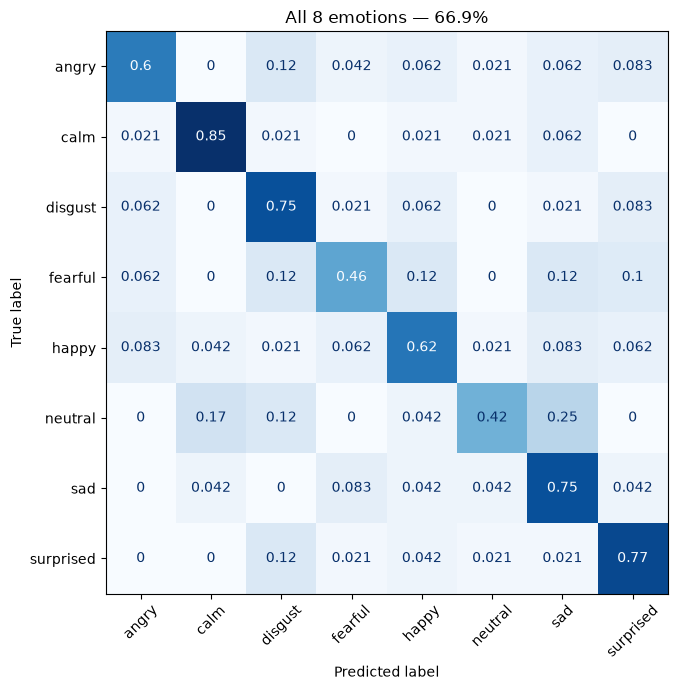

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_estimator(model8, X8te, y8te, normalize='true',
                                      cmap='Blues', ax=ax, colorbar=False,
                                      xticks_rotation=45)
ax.set_title(f'All 8 emotions — {acc8:.1%}')
plt.tight_layout(); plt.show()

The confusion matrix is more interesting than the accuracy. Two things keep
coming up:

- **neutral vs calm**: they sound almost the same, humans disagree on these too.
- **angry / fearful / surprised** get mixed up with each other.

Both come from the same thing: averaged energy features are much better at
arousal than valence. Angry and happy are both loud. What tells them apart is
mostly pitch contour and context, which is what got averaged away in section 3.

<a id='9'></a>
## 9. Predicting one file

Same steps a new clip would go through.

In [22]:
import joblib
from speech_emotion.predict import predict_file

MODEL_DIR = REPO_ROOT / 'models'; MODEL_DIR.mkdir(exist_ok=True)
bundle = {'model': speaker_model, 'emotions': OBSERVED_EMOTIONS,
          'split': 'speaker', 'accuracy': float(acc_speaker)}
joblib.dump(bundle, MODEL_DIR / 'notebook_model.joblib')

# a clip from a held-out actor
held_out_actor = sorted(set(groups[test_idx].tolist()))[0]
clip = meta[(meta['actor'] == held_out_actor) &
            (meta['emotion'].isin(OBSERVED_EMOTIONS))].iloc[3]

print(f"file:  {Path(clip['path']).name}")
print(f"truth: {clip['emotion']}  (actor {clip['actor']}, {clip['gender']}, held out)")
display(Audio(filename=str(clip['path'])))

label, probs = predict_file(clip['path'], bundle)
print(f'\npredicted: {label}\n')
for name, p in sorted(probs.items(), key=lambda kv: -kv[1]):
    print(f'  {name:<10} {p:6.1%} {"#" * int(round(p * 30))}')

file:  03-01-02-01-02-02-04.wav
truth: calm  (actor 4, female, held out)



predicted: fearful

  fearful     95.8% #############################
  disgust      3.3% #
  calm         0.8% 
  happy        0.1% 


This one's wrong: the clip is `calm` and the model says `fearful`. I left it
in rather than re-running until I got a correct one. At 59% on unseen speakers,
around 2 in 5 predictions are wrong, so try a few other held-out clips to get a
feel for it.

<a id='10'></a>
## 10. Summary

- **Features:** 180 per clip (40 MFCC + 12 chroma + 128 mel), each averaged over
  time.
- **Averaging** throws away timing, including pitch contour, which limits how
  well this can do.
- **The split matters more than the model.** Random vs speaker split gives very
  different accuracy with the same data and model.
- **Scaling** makes a big difference since the features are on very different
  scales. Putting the scaler in a `Pipeline` also avoids leaking test data.
- **Arousal is easier than valence.** Loud vs quiet is easy for these features,
  positive vs negative at the same energy is not.

### Next steps

1. **Delta features:** `librosa.feature.delta` on the MFCCs adds 80 columns with
   some timing information.
2. **Augmentation:** pitch shift, time stretch and noise don't change the
   emotion, and the training set is small.
3. **CNN on the mel spectrogram** so there's no averaging at all.

---

More detail: [`docs/LEARNING_NOTES.md`](../docs/LEARNING_NOTES.md),
[`docs/RESULTS.md`](../docs/RESULTS.md), [`docs/DATASET.md`](../docs/DATASET.md)